In [1]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# import os
# %matplotlib inline

In [2]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString
from opentnsim import graph

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr

# load OpenTNSim modules
from opentnsim.core import Identifiable, Movable 
from opentnsim.core.vessel_properties import VesselProperties
from opentnsim.graph import HasMultiDiGraph
from opentnsim.vessel_traffic_service import VesselTrafficService
from opentnsim.port.mixins.port import IsPort, HasPortAccess
from opentnsim.port.mixins.terminal import IsTerminal, HasTerminal
from opentnsim.port.mixins.berth import IsJetty, IsQuay
from opentnsim.port.mixins.anchorage_area import IsAnchorage, PassesAnchorage
from opentnsim.port.mixins import tidal_accessibility
from opentnsim.port.mixins.tidal_accessibility import HasDraughtRestrictions
from opentnsim.port.rule_constructor import vessel_characteristics, vessel_direction, vessel_type
from opentnsim.port.tidal_window_constructor import vessel_specifications, \
                                                    vertical_tidal_window_specifications, \
                                                    vertical_tidal_window_input, \
                                                    horizontal_tidal_window_specifications, \
                                                    horizontal_tidal_window_method, \
                                                    horizontal_tidal_window_input, \
                                                    tidal_period, \
                                                    accessibility, \
                                                    NetworkProperties

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np

# package(s) for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import os

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
path = os.getcwd()
data_path = os.path.join(path, "data", "Port_accessibility")

In [5]:
df = pd.read_csv(os.path.join(data_path,"rotterdam_data.csv"), delimiter=';', encoding='ISO-8859-1', on_bad_lines='skip')

In [6]:
df['TIME'] = df['WAARNEMINGDATUM'] + ' ' + df['WAARNEMINGTIJD (MET/CET)']
df['TIME'] = pd.to_datetime(df['TIME'], format = "%d-%m-%Y %H:%M:%S")
df = df[['TIME','MEETPUNT_IDENTIFICATIE','NUMERIEKEWAARDE']]
df = df.rename(columns={'MEETPUNT_IDENTIFICATIE':'Location','NUMERIEKEWAARDE':'Water level'})
df = df.set_index('TIME')

In [7]:
df['Water level'] = df['Water level'].apply(lambda x: x if x < 200 else np.nan)
df['Water level'] = df['Water level'].interpolate()

In [8]:
botlek_data = df[df['Location'] == 'Geulhaven Radarpost 10']
HvH_data = df[df['Location'] == 'Hoek van Holland']
Moerdijk_data = df[df['Location'] == 'Moerdijk']
Rotterdam_data = df[df['Location'] == 'Rotterdam']
botlek_data.pop('Location')
HvH_data.pop('Location')
Moerdijk_data.pop('Location')
Rotterdam_data.pop('Location');

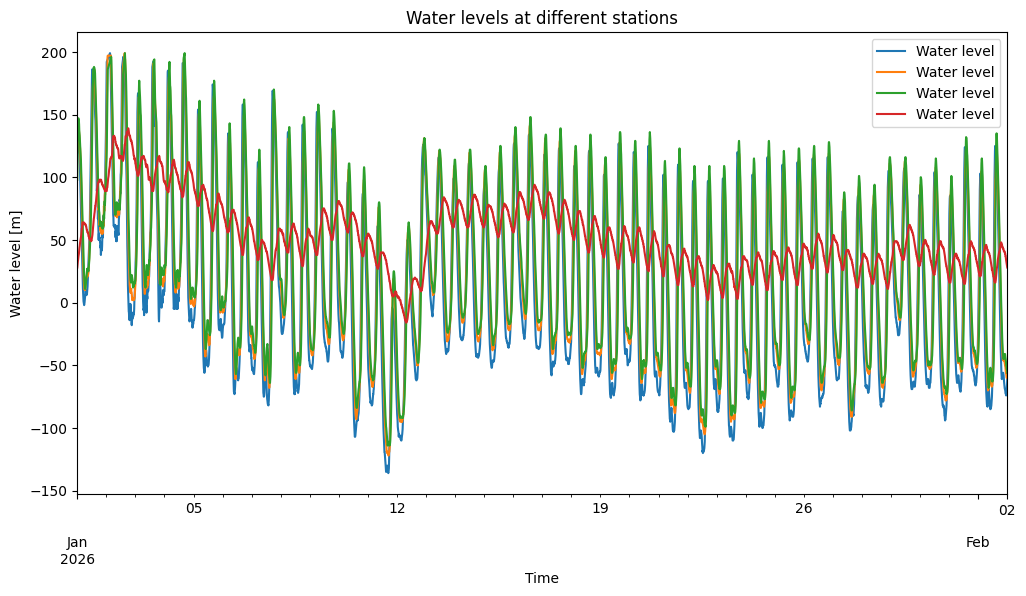

In [9]:
fig, ax = plt.subplots(figsize=(12,6))

HvH_data.plot(ax=ax, label="Hoek van Holland")
botlek_data.plot(ax=ax, label="Botlek")
Rotterdam_data.plot(ax=ax, label="Rotterdam")
Moerdijk_data.plot(ax=ax, label="Moerdijk")

ax.set_xlabel("Time")
ax.set_ylabel("Water level [m]")
ax.set_title("Water levels at different stations")

ax.legend()
plt.show()

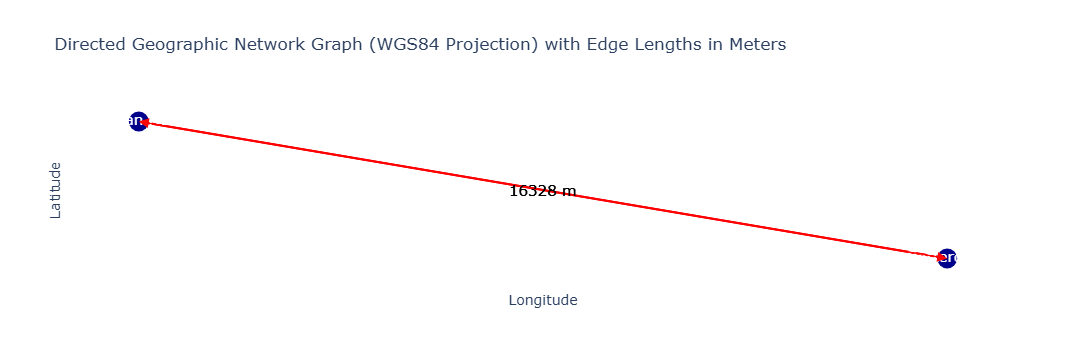

In [10]:
import networkx as nx
from shapely.geometry import Point

# 1) coordinaten (lon, lat)
coords = {
    "Hoek van Holland": (4.1198809998947, 51.977573995722),
    "Rotterdam":(4.3125309998907, 51.891813995749) #(4.481362, 51.912423) (4.3125309998907, 51.891813995749), #Geulhaven Radarpost 10
}

# 2) graph
FG = nx.DiGraph()

# 3) nodes
for name, (lon, lat) in coords.items():
    FG.add_node(name, geometry=Point(lon, lat))

# 4) edges (gericht) - bijvoorbeeld beide richtingen
edge_length = opentnsim.graph.calculate_distance(Point(coords['Hoek van Holland']),Point(coords['Rotterdam']))
edge_geometry_in = LineString([Point(coords['Hoek van Holland']),Point(coords['Rotterdam'])])
edge_geometry_out = LineString([Point(coords['Rotterdam']),Point(coords['Hoek van Holland'])])

FG.add_edge("Hoek van Holland", "Rotterdam", weight=1, geometry = edge_geometry_in, length_m= edge_length)
FG.add_edge("Rotterdam", "Hoek van Holland", weight=1, geometry = edge_geometry_out, length_m= edge_length)

#Geulhaven Radarpost 10
# 5) plotkan h
opentnsim.graph.plot_graph(FG)

Vessel proporties


In [11]:
vessel_length = 318.2 #m
vessel_beam = 42.8 #m 
vessel_draught = 10 #15 #m 
vessel_speed = 4.5 #m/s ?

vessel_capacity = 7404 # TEU

#KARLSKRONA (DESIGN VESSEL UIT VESSEL VIEW DASHBOARD) 

infrastructure

In [12]:
waterway_length = edge_length #25000 #meters
waterway_depth = 10.5 #meters (NGD: nautical guaranteed depth = MBL: maintained bed level) 
# volgend PIANC depth = draught + ukc  

harbour_basin_depth = 17.5
anchorage_area_depth = 17.5


tidal restrictions

create environment 

In [13]:

# 1. Bepaal de simulatieperiode op basis van je echte data
# We gebruiken de index van 'df' omdat je die eerder op 'TIME' hebt gezet
simulation_start = df.index.min()
simulation_stop = df.index.max()

# 2. Maak de tijdreeks aan (optioneel, voor hydrodynamische controles)
# Hier gebruiken we de frequentie van je data (bijv. 10 minuten)
timestep = pd.Timedelta(minutes=10) 
time_series = pd.date_range(simulation_start, simulation_stop, freq=timestep)

# 3. Initialiseer de Simpy Environment
# initial_time is het aantal seconden sinds de epoch (1970-01-01)
env = simpy.Environment(initial_time=simulation_start.timestamp())

# 4. Voeg metadata toe aan de environment voor OpenTNSim
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

print(f"Simulatie start: {env.simulation_start}")
print(f"Simulatie stop:  {env.simulation_stop}")
print(f"Huidige env.now (als timestamp): {env.now}")

Simulatie start: 2026-01-01 00:00:00
Simulatie stop:  2026-02-02 00:00:00
Huidige env.now (als timestamp): 1767225600.0


In [14]:
# add graph to environment
env.graph = FG


Adding vessel traffic service

In [15]:
# Maak een lege xarray dataset
hydrodynamic_data = xr.Dataset()

# Gebruik de tijdreeks uit je dataframe (ervan uitgaande dat die voor beide stations gelijk is)
time_series = HvH_data.index

# Maak de Water level DataArray op basis van je echte metingen
# We gebruiken de stationsnamen die in je grafiek (FG.nodes) voorkomen
# water_level_data = xr.DataArray(
#     data=[HvH_data['Water level'].values, botlek_data['Water level'].values],
#     coords={'STATION': ['Hoek van Holland', 'Botlek'], 'TIME': time_series},
#     dims=('STATION', 'TIME')
# )

water_level_data = xr.DataArray(
    data=[HvH_data['Water level'].values, Rotterdam_data['Water level'].values],
    coords={'STATION': ['Hoek van Holland', 'Rotterdam'], 'TIME': time_series},
    dims=('STATION', 'TIME')
)
# Definieer de bodemdiepte (MBL). 
# Je kunt hier waterway_depth uit cel 11 gebruiken
MBL_values = np.full((2, len(time_series)), waterway_depth)
MBL_data = xr.DataArray(
    data=MBL_values,
    coords={'STATION': ['Hoek van Holland', 'Rotterdam'], 'TIME': time_series},
    #coords={'STATION': ['Hoek van Holland', 'Botlek'], 'TIME': time_series},
    dims=('STATION', 'TIME')
)

hydrodynamic_data['Water level'] = water_level_data/100
hydrodynamic_data['MBL'] = MBL_data

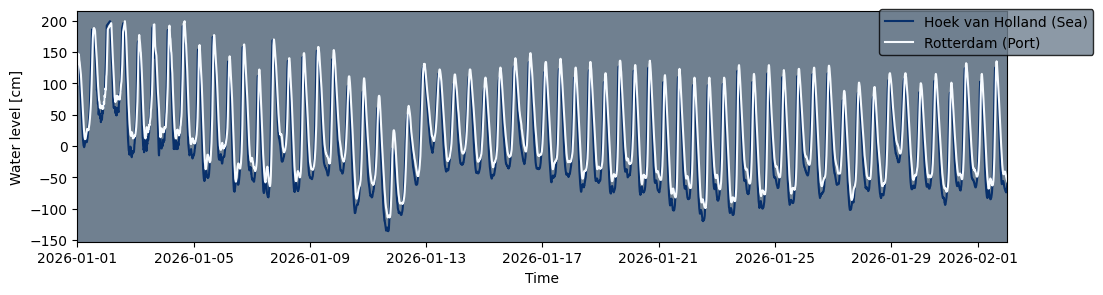

In [16]:
fig, ax = plt.subplots(figsize=[12, 3])
ax.set_facecolor('slategrey')
cmap = plt.get_cmap('Blues_r')

ax.plot(HvH_data.index, HvH_data['Water level'], color=cmap(0), label='Hoek van Holland (Sea)')
ax.plot(Rotterdam_data.index, Rotterdam_data['Water level'], color=cmap(cmap.N), label='Rotterdam (Port)')
#ax.plot(botlek_data.index, botlek_data['Water level'], color=cmap(cmap.N), label='Botlek (Port)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel('Time')
ax.set_ylabel('Water level [cm]')
ax.set_xlim(HvH_data.index[0], HvH_data.index[-1])
ax.legend(loc='upper right', frameon=True, bbox_to_anchor=[1.1, 1.0375], facecolor='slategray', edgecolor='k')

plt.show()

#0 is NAP?

In [17]:
vessel_traffic_service = VesselTrafficService(hydrodynamic_data = hydrodynamic_data)
env.vessel_traffic_service = vessel_traffic_service

In [18]:
#percentage of the draught as UKC (10% of draught is common)
ukc_percentage_sea = 0.10 # 10% of draught 
ukc_percentage_canal = 0.10

#static value as UKC (0.5 m is common, but not in combination with ukc_percentage)
ukc_static_sea = 0.0 #meters
ukc_static_canal = 0.0 #meters

#freshwater allowance as percentage of draught as additional UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage common)
fwa_sea = 0.0 #% of draught
fwa_canal = 0.0 #% of draught

In [19]:
ukc_p = [ukc_percentage_sea,ukc_percentage_canal] #percentage of the UKC (10% of draught is common)
ukc_s = [ukc_static_sea,ukc_static_canal] #static value of the UKC
fwa = [fwa_sea,fwa_canal] #freshwater allowance as percentage of UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage)

network_properties = NetworkProperties()
for index,node in enumerate(FG.nodes):
    FG.nodes[node]['Vertical tidal restriction'] = {}
    vertical_tidal_window_inputs = []

    vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.inbound)
    window_specification = vertical_tidal_window_specifications(ukc_s = ukc_s[index],
                                                                ukc_p = ukc_p[index],
                                                                fwa = fwa[index],)
    
    vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                    window_specifications = window_specification))

    network_properties.append_vertical_tidal_restriction_to_network(env.graph,node,vertical_tidal_window_inputs)

ADDING port infratructure

In [20]:
# Draai dit en kijk goed naar de spelling in de output
print("Beschikbare nodes in FG:", list(FG.nodes))

Beschikbare nodes in FG: ['Hoek van Holland', 'Rotterdam']


In [21]:
port = IsPort(env=env, name = "Port", port_entry_nodes=['Hoek van Holland','Rotterdam'])

In [22]:
anchorage_depth = 16
anchorage = IsAnchorage(env=env, capacity=20, name = 'Anchorage', node = 'Hoek van Holland', geometry=env.graph.nodes['Hoek van Holland']['geometry'], port = port, depth=anchorage_depth)

In [23]:
# Gebruik de exacte naam van je node uit je notebook
haven_node = "Rotterdam"

# Maak de Jetty aan op de juiste plek (Botlek/Geulhaven)
jetty = IsJetty(
    env=env, 
    length=400, 
    depth=harbour_basin_depth, 
    name='Jetty', 
    node=haven_node
)

# Maak de Terminal aan en koppel deze aan de Port
terminal = IsTerminal(
    env=env, 
    name='Terminal', 
    berths=[jetty], 
    port=port
)

print(f"Jetty en Terminal succesvol geplaatst op node: {haven_node}")

Jetty en Terminal succesvol geplaatst op node: Rotterdam


create agents

In [24]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (HasPortAccess,
     HasTerminal,
     PassesAnchorage,
     HasDraughtRestrictions,
     HasMultiDiGraph,
     Identifiable, # allows to give the object a name and a random ID,
     Movable,      # allows the object to move, with a fixed speed, while logging this activity
     VesselProperties,
    ), 
    {}
)


In [25]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    yield from vessel.move()

In [26]:
# create vessel from a dict 
path = nx.dijkstra_path(env.graph, 'Hoek van Holland', 'Rotterdam' )
data_vessel = {
    "env": env,                                       # needed for simpy simulation
    "name": "Vessel 1",                               # required by Identifiable
    "geometry": env.graph.nodes[path[0]]['geometry'], # required by Locatable
    "route": path,                                    # required by Routeable
    "v": vessel_speed,                                # required by Movable, 1 m/s to check if the distance is covered in the expected time
    "bound": 'inbound',
    "terminal": terminal,
    "berthing_time":15, #minutes
    "loading_time": 12, #hours
    "deberthing_time":5, #minutes
    "next_destination": 'Hoek van Holland',
    "type":"tanker",
    "L":vessel_length,
    "B":vessel_beam,
    "T":vessel_draught,
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel = Vessel(**data_vessel)

# start the simulation
vessel.mission = env.process(mission(env, vessel))

In [27]:
# 1. De VTS MOET in de environment zitten onder deze exacte naam:
env.vessel_traffic_service = vessel_traffic_service 

# 2. Het schip moet weten dat hij bij deze environment hoort:
vessel.env = env

In [28]:
env.run()

In [29]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

print("'{}' logbook data:".format(vessel.name))  
print('')

display(df)

if not df.empty:
    trip_distance = opentnsim.graph.calculate_distance_along_path(FG, vessel.route)
    trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
    print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
    print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
    print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
else:
    print("The port was not accessible for vessel")
print('')
print('')

print(vessel.v)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node Hoek van Holland to node Rot...,2026-01-01 01:00:00.000000,0.000000,POINT (4.1198809998947 51.977573995722)
1,Sailing from node Hoek van Holland to node Rot...,2026-01-01 02:00:28.536671,16328.415021,POINT (4.3125309998907 51.891813995749)
2,Berthing start,2026-01-01 02:00:28.536671,16328.415021,POINT (4.3125309998907 51.891813995749)
3,Berthing stop,2026-01-01 02:15:28.536671,16328.415021,POINT (4.3125309998907 51.891813995749)
4,Loading start,2026-01-01 02:15:28.536671,16328.415021,POINT (4.3125309998907 51.891813995749)
5,Loading stop,2026-01-01 14:15:28.536671,16328.415021,POINT (4.3125309998907 51.891813995749)
6,Deberthing start,2026-01-01 14:15:28.536671,16328.415021,POINT (4.3125309998907 51.891813995749)
7,Deberthing stop,2026-01-01 14:20:28.536671,16328.415021,POINT (4.3125309998907 51.891813995749)
8,Sailing from node Rotterdam to node Hoek van H...,2026-01-01 14:20:28.536671,16328.415021,POINT (4.3125309998907 51.891813995749)
9,Sailing from node Rotterdam to node Hoek van H...,2026-01-01 15:20:57.073343,32656.830042,POINT (4.1198809998947 51.977573995722)


'Vessel 1' travelled a distance of 16328.4 meters
'Vessel 1' took 51657.1 seconds to arrive at its destination
'Vessel 1' travelled at an average speed of 0.3 meters per second


4.5


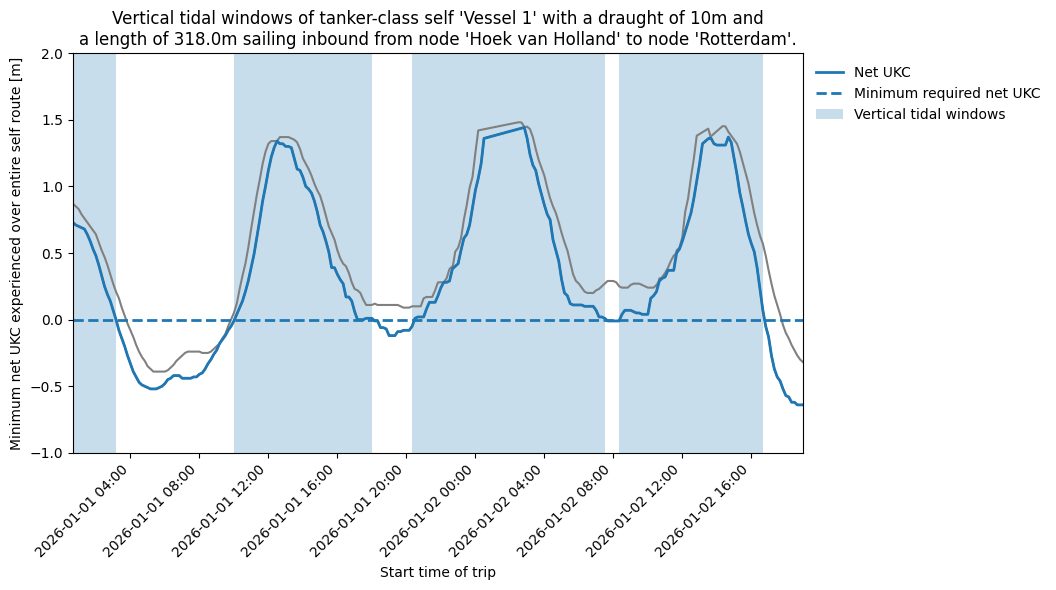

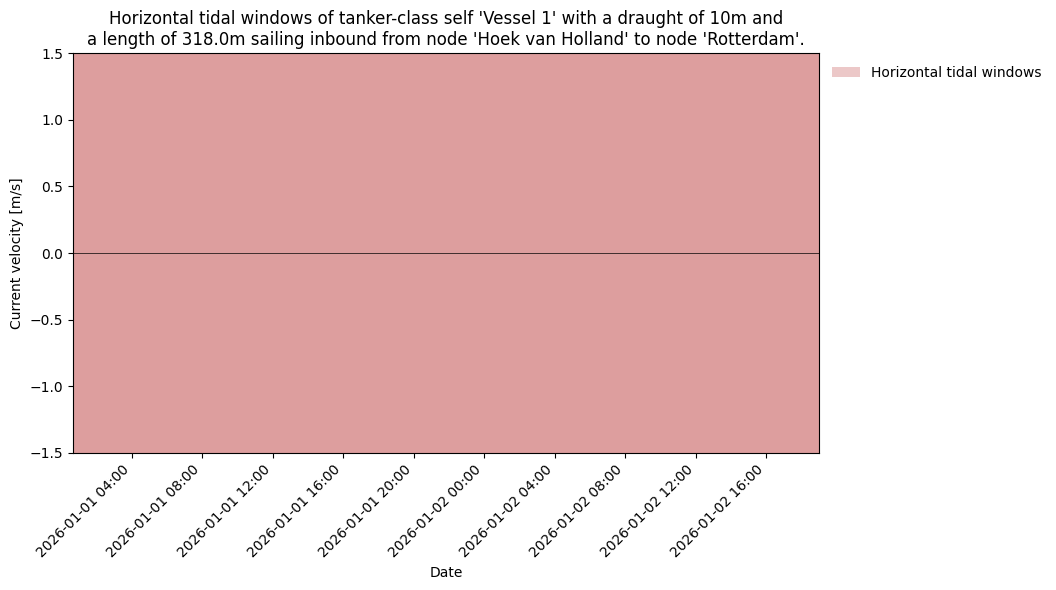

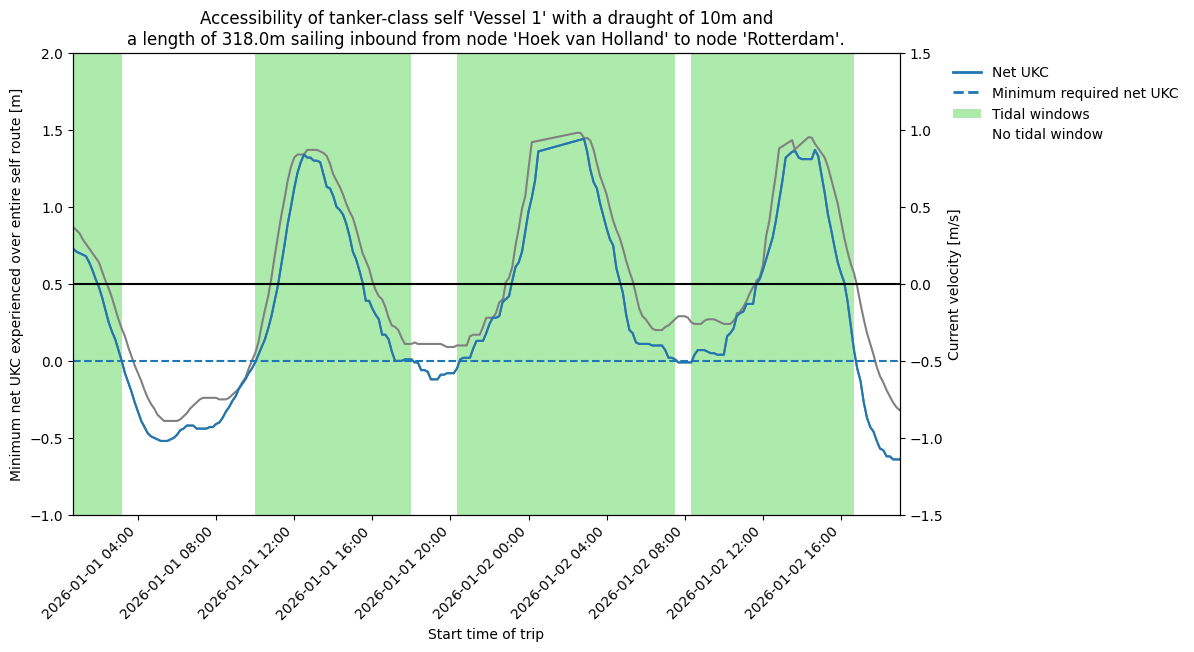

In [30]:
#Inbound trip
trip_index = 0
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

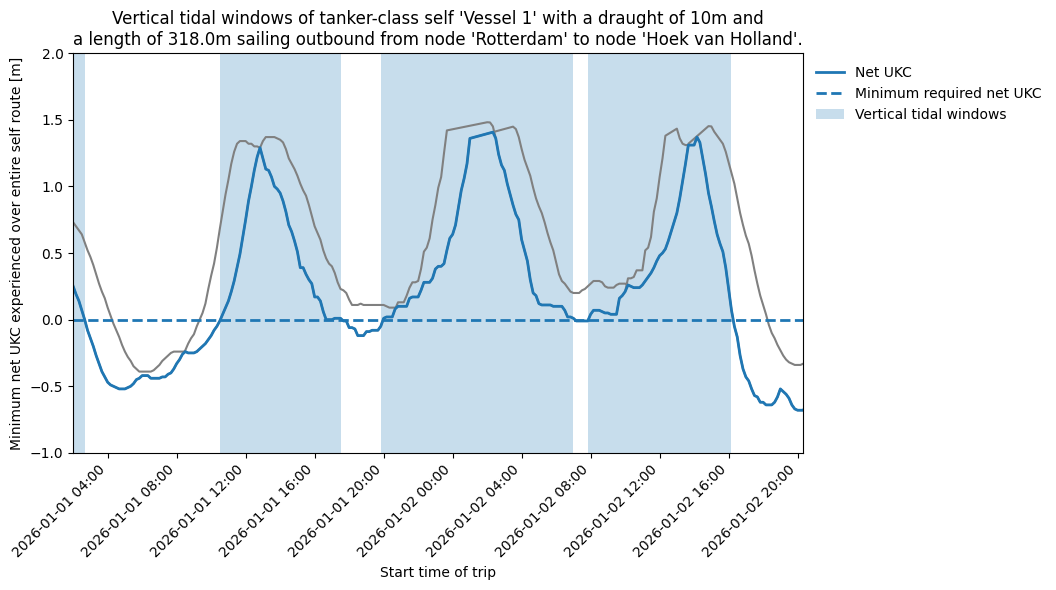

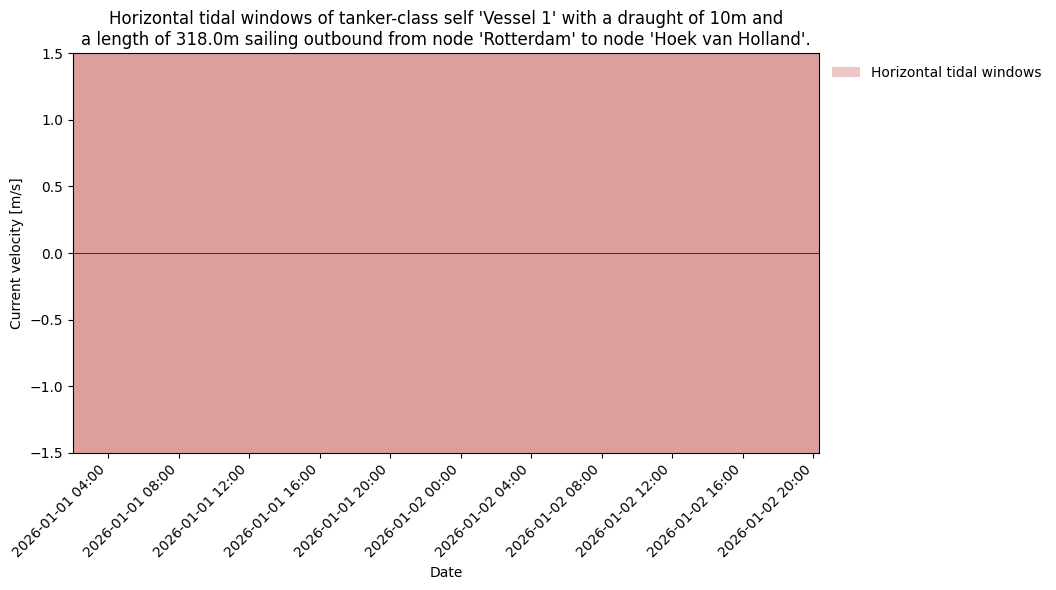

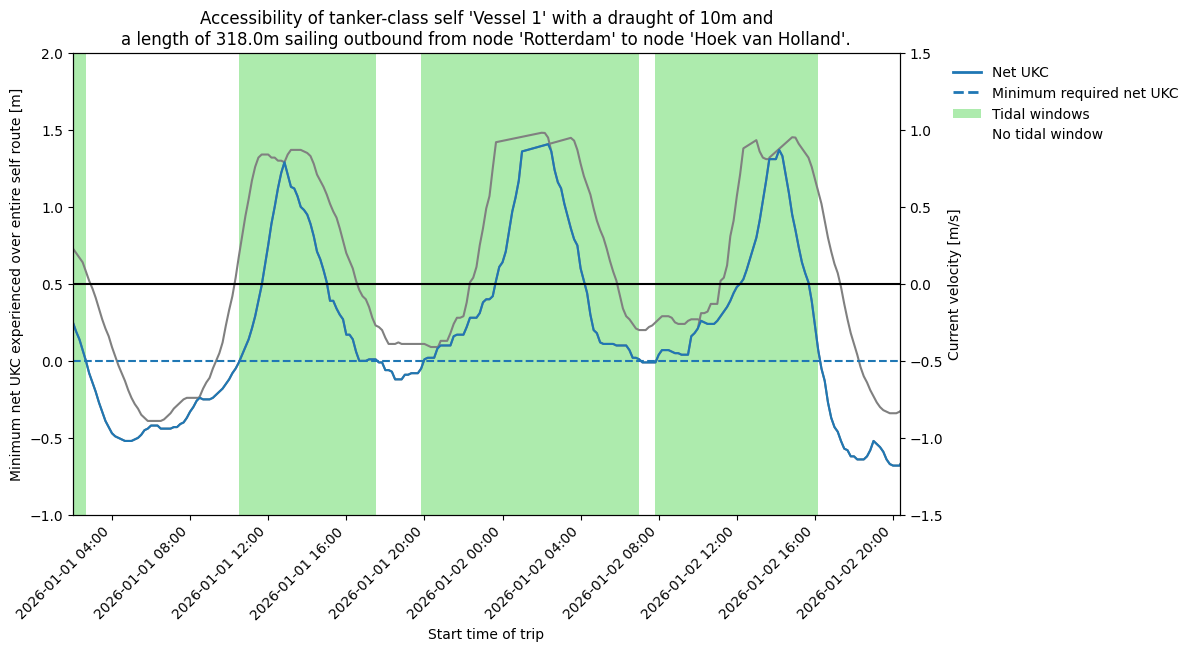

In [31]:
#Outbound trip
trip_index = 1
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

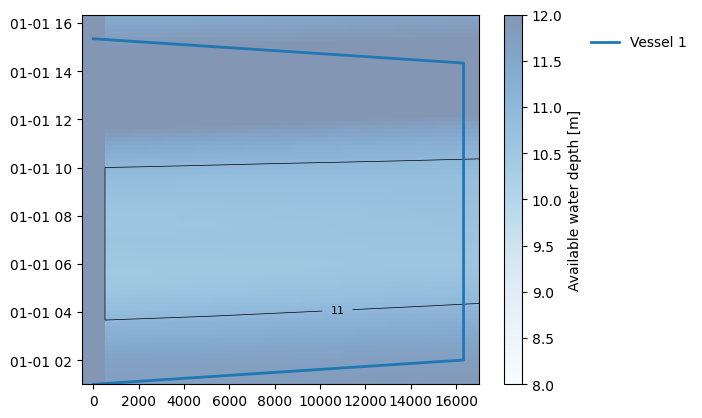

In [32]:
from opentnsim.port.visualizations import plot_vessels_over_route
fig = plot_vessels_over_route(env,'Hoek van Holland','Rotterdam',env.vessels,levels=[vessel.T*1.1],xmin=-500, xmax=17000, zmin=8,zmax=12)
fig

percentage tidal window calculation 


In [33]:
required_depth = vessel_draught * (1 + ukc_p[0])  # d= T + uck_percentage(10%*T)

# print(required_depth)
# print(ukc_p)
# print(ukc_s)

In [34]:
# total waterdepth over space and time
H = hydrodynamic_data["MBL"] + hydrodynamic_data["Water level"] 

# print(hydrodynamic_data["MBL"])
# print(hydrodynamic_data["Water level"] )
# print(H)

In [35]:
# toegagnelijk per node

accessible_node = H >= required_depth

# kanaal is alleen toegankelijk als alle node voldoen aan de tidal window eis.  
accessible_channel = accessible_node.all(dim="STATION")

#print(accessible_channel)

In [36]:
# naar pandas
acc= accessible_channel.to_series()

# percentage per dag
daily_accessibility_pct = 100 * acc.astype(int).resample("D").mean()
daily_accessibility_pct.name = "Daily tidal accessibility (%)"
#display(daily_accessibility_pct)

In [37]:
avg_water_level = H.resample(TIME="1D").mean()  # Gemiddelde waterstand per dag
max_water_level = H.resample(TIME="1D").max()
min_water_level = H.resample(TIME="1D").min()

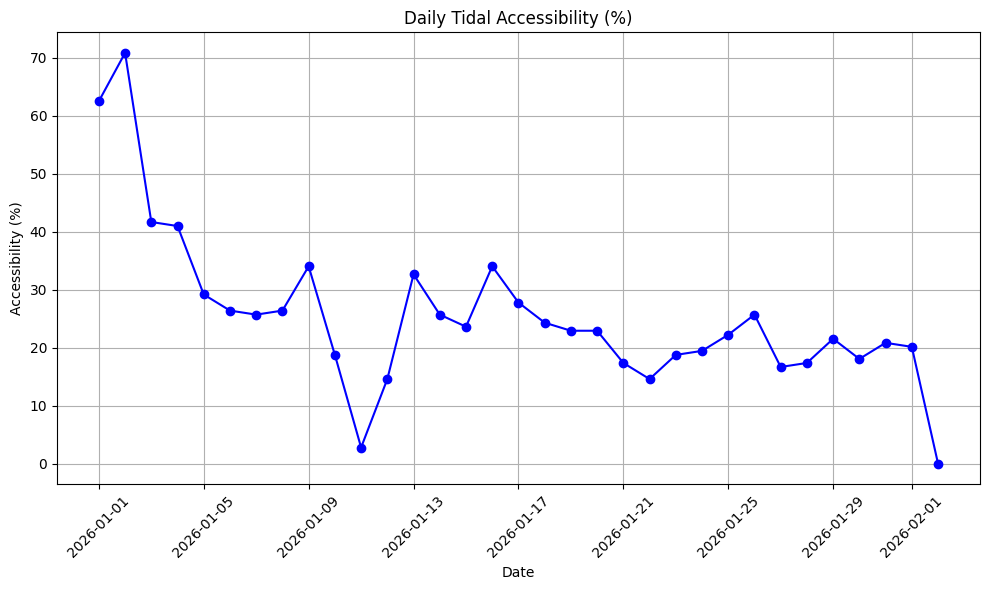

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(daily_accessibility_pct.index, daily_accessibility_pct.values, marker='o', linestyle='-', color='b')
plt.title("Daily Tidal Accessibility (%)")
plt.xlabel("Date")
plt.ylabel("Accessibility (%)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

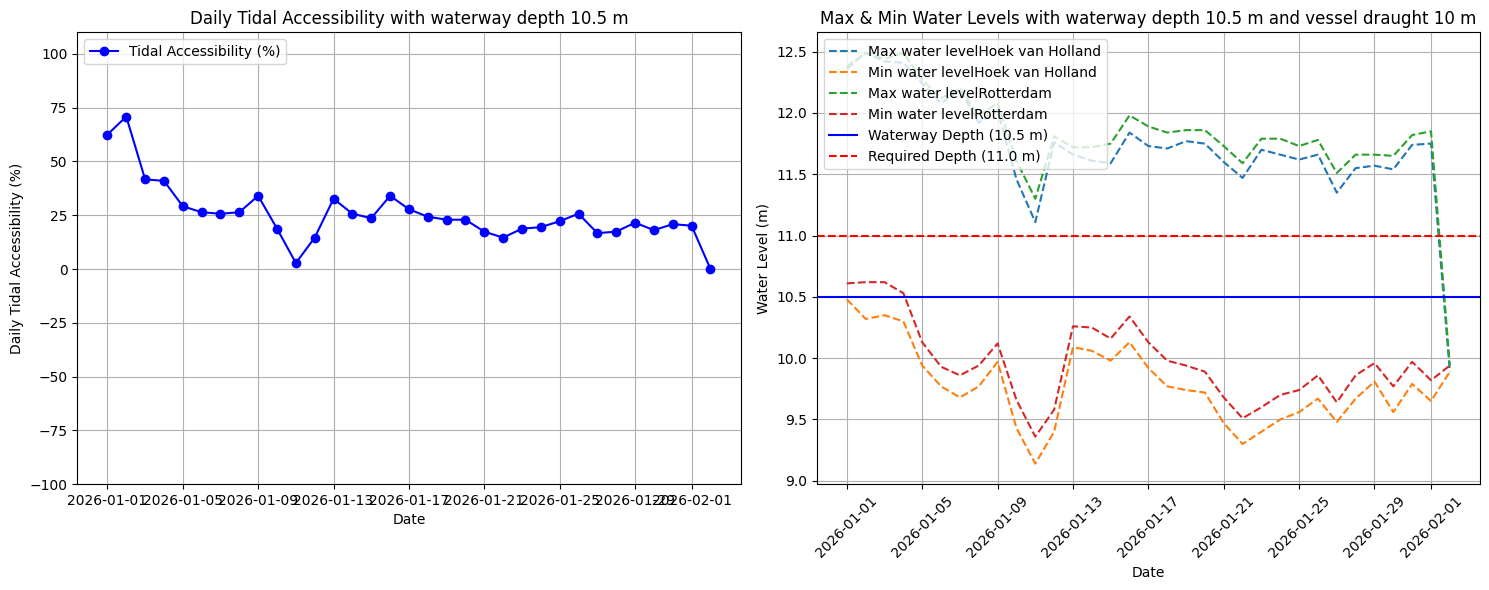

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# subplot: daily tidal accessibility
ax1.plot(daily_accessibility_pct.index, daily_accessibility_pct.values, marker='o', linestyle='-', color='b', label='Tidal Accessibility (%)')
ax1.set_title(f"Daily Tidal Accessibility with waterway depth {waterway_depth} m")
ax1.set_xlabel("Date")
ax1.set_ylabel("Daily Tidal Accessibility (%)")
ax1.set_ylim(-100, 110) 
ax1.grid(True)
ax1.legend(loc='upper left')

# subplot 2: Min and max water levels 
stations = max_water_level.coords['STATION'].values

for station in stations:
    # Plot de maximale waterstand voor dit station
    ax2.plot(max_water_level.coords['TIME'], max_water_level.sel(STATION=station).values, linestyle='--', label=f'Max water level{station}')
    # Plot de minimale waterstand voor dit station
    ax2.plot(min_water_level.coords['TIME'], min_water_level.sel(STATION=station).values, linestyle='--', label=f'Min water level{station}')
    # Plot de  waterstand voor dit station
    #ax2.plot(H.coords['TIME'], H.sel(STATION=station).values, linestyle='--', label=f'Water level{station}')
# waterway depth
ax2.axhline(y=waterway_depth, color='blue', linestyle='-', label=f'Waterway Depth ({waterway_depth} m)')
ax2.axhline(y=required_depth, color='red', linestyle='--', label=f'Required Depth ({required_depth} m)')

ax2.set_title(f"Max & Min Water Levels with waterway depth {waterway_depth} m and vessel draught {vessel_draught} m")
ax2.set_xlabel("Date")
ax2.set_ylabel("Water Level (m)")
ax2.grid(True)
ax2.legend(loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [40]:
print(waterway_depth) # is nu gelijk aan de MBL? 
print(waterway_length)

10.5
16328.415020948145


In [42]:
# Print de berthing time en loading time
print("Berthing Time:", data_vessel["berthing_time"], "minutes")
print("Loading Time:", data_vessel["loading_time"], "hours")
print("deberthing_time:", data_vessel["deberthing_time"], "minutes")

Berthing Time: 15 minutes
Loading Time: 12 hours
deberthing_time: 5 minutes


In [43]:
sailing_in = (waterway_length / vessel_speed ) / 3600 # uren  #vessel speed laag? 
sailing_out = sailing_in
#waiting tidal window = ? 

# transit time = kanaal in + bearthing + loading + deberting + kanaal uit + waiting tidal window? 

transit_time_in = sailing_in + (data_vessel["berthing_time"] / 60) + data_vessel["loading_time"] + (data_vessel["deberthing_time"] / 60) + sailing_out  
print(f"Time for a vessel to compleet a full cycle of entering an leaving the port: {transit_time_in:.4} hours")
print(f"time for vessel to sail through the canal {sailing_in:.3} hours")

Time for a vessel to compleet a full cycle of entering an leaving the port: 14.35 hours
time for vessel to sail through the canal 1.01 hours


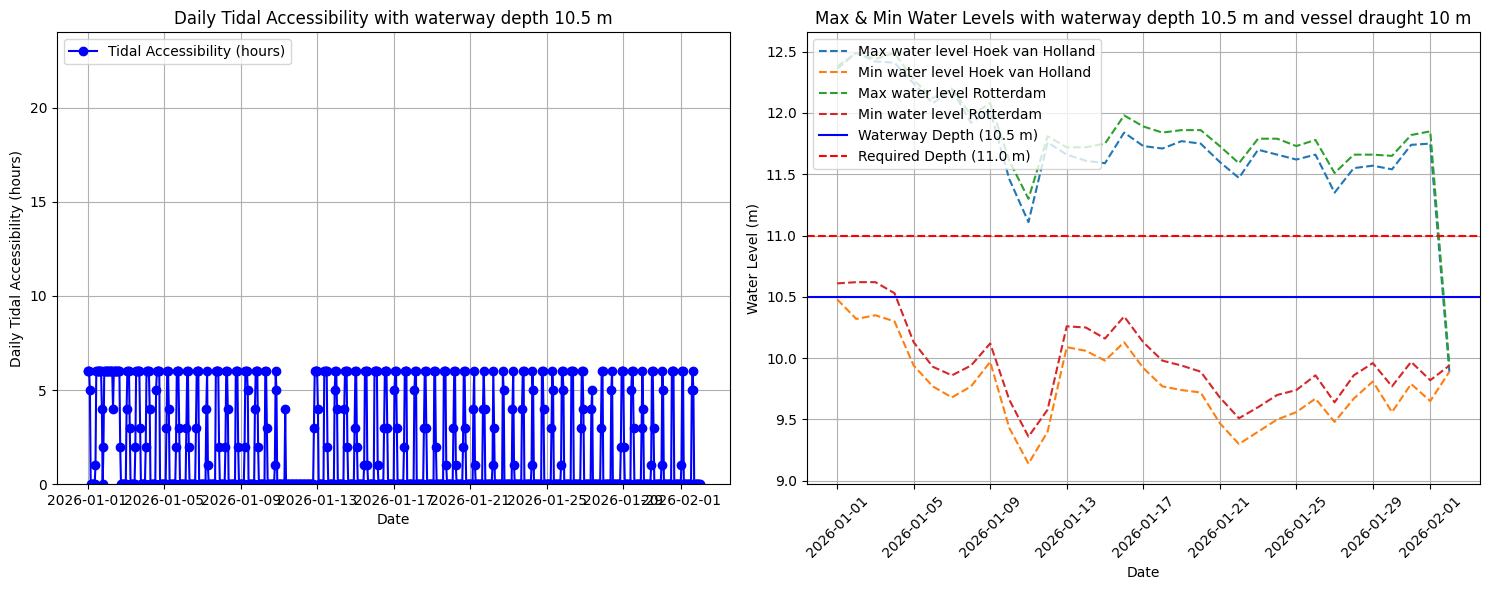

TIME
2026-01-01 00:00:00    6
2026-01-01 01:00:00    6
2026-01-01 02:00:00    6
2026-01-01 03:00:00    5
2026-01-01 04:00:00    0
                      ..
2026-02-01 20:00:00    0
2026-02-01 21:00:00    0
2026-02-01 22:00:00    0
2026-02-01 23:00:00    0
2026-02-02 00:00:00    0
Freq: h, Length: 769, dtype: int64


In [47]:
# Veronderstel dat 'acc' de binair toegankelijke data is (1 voor toegankelijk, 0 voor niet-toegankelijk)

# Stap 1: Resample de toegankelijkheid per dag en tel de uren per dag (hoeveel uur per dag het tidal window beschikbaar was)
daily_accessibility_hours = acc.resample("h").sum()  # Aantal uren per dag (hoeveel keer 1, oftewel beschikbaar)

# Maak de plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# subplot 1: daily tidal accessibility in uren
ax1.plot(daily_accessibility_hours.index, daily_accessibility_hours.values, marker='o', linestyle='-', color='b', label='Tidal Accessibility (hours)')
ax1.set_title(f"Daily Tidal Accessibility with waterway depth {waterway_depth} m")
ax1.set_xlabel("Date")
ax1.set_ylabel("Daily Tidal Accessibility (hours)")
ax1.set_ylim(0, 24)  # Omdat het maximum aantal uren 24 is
ax1.grid(True)
ax1.legend(loc='upper left')

# subplot 2: Max and Min Water Levels
stations = max_water_level.coords['STATION'].values

for station in stations:
    # Plot de maximale waterstand voor dit station
    ax2.plot(max_water_level.coords['TIME'], max_water_level.sel(STATION=station).values, linestyle='--', label=f'Max water level {station}')
    # Plot de minimale waterstand voor dit station
    ax2.plot(min_water_level.coords['TIME'], min_water_level.sel(STATION=station).values, linestyle='--', label=f'Min water level {station}')
    
# Voeg de waterwegdiepte en vereiste diepte toe
ax2.axhline(y=waterway_depth, color='blue', linestyle='-', label=f'Waterway Depth ({waterway_depth} m)')
ax2.axhline(y=required_depth, color='red', linestyle='--', label=f'Required Depth ({required_depth} m)')

ax2.set_title(f"Max & Min Water Levels with waterway depth {waterway_depth} m and vessel draught {vessel_draught} m")
ax2.set_xlabel("Date")
ax2.set_ylabel("Water Level (m)")
ax2.grid(True)
ax2.legend(loc='upper left')

# Draai de x-as labels voor betere leesbaarheid
plt.xticks(rotation=45)

# Zorg ervoor dat de layout goed is
plt.tight_layout()

# Toon de grafiek
plt.show()

# Print de daily_accessibility_hours
print(daily_accessibility_hours)

In [ ]:
# hoeveel schepen kunnen er per dag naar binnen 

# 6 uur -> 5 schepen ? als er 1 per dag naar binnen kan 